No handles with labels found to put in legend.


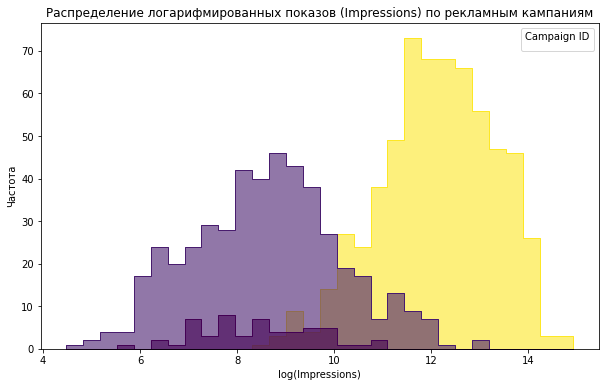

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Загрузка данных
data = pd.read_csv("conversion.csv")

# Логарифмирование значений Impressions (натуральный логарифм)
data["Log_Impressions"] = np.log(data["Impressions"] + 1)  # +1 чтобы избежать log(0)

# Построение графика
plt.figure(figsize=(10, 6))
sns.histplot(
    data=data,
    x="Log_Impressions",
    hue="xyz_campaign_id",
    element="step",
    bins=30,
    palette="viridis",
    alpha=0.6,
)
plt.title("Распределение логарифмированных показов (Impressions) по рекламным кампаниям")
plt.xlabel("log(Impressions)")
plt.ylabel("Частота")
plt.legend(title="Campaign ID")
plt.show()

In [2]:
# Фильтрация строк, где Clicks > 0
filtered_data = data[data["Clicks"] > 0]

# Расчет CTR ( Clicks/Impressions)
filtered_data["CTR"] = filtered_data["Clicks"] / filtered_data["Impressions"]

# Описательные статистики CTR
print(filtered_data["CTR"].describe())

# Поиск ad_id с максимальным CTR
max_ctr_id = filtered_data.loc[filtered_data["CTR"].idxmax(), "ad_id"]
print(f"\nОбъявление с наибольшим CTR: ad_id = {max_ctr_id}")

count    936.000000
mean       0.000201
std        0.000094
min        0.000031
25%        0.000137
50%        0.000182
75%        0.000247
max        0.001059
Name: CTR, dtype: float64

Объявление с наибольшим CTR: ad_id = 738637


/opt/tljh/user/lib/python3.7/site-packages/ipykernel_launcher.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  """


In [3]:
filtered_data["CTR"]

0       0.000136
1       0.000112
3       0.000235
4       0.000242
6       0.000192
          ...   
1138    0.000223
1139    0.000188
1140    0.000185
1141    0.000171
1142    0.000222
Name: CTR, Length: 936, dtype: float64

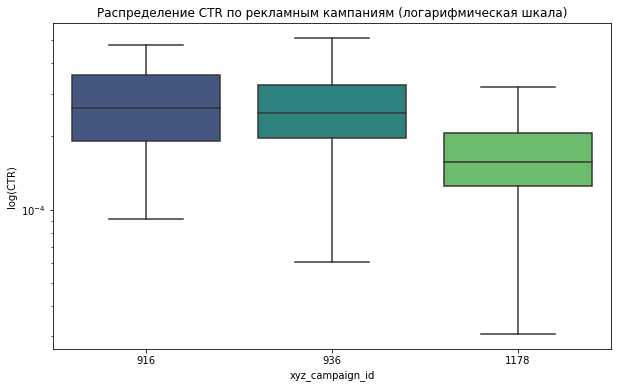

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.boxplot(
    data=filtered_data,
    x="xyz_campaign_id",
    y="CTR",
    palette="viridis",
    showfliers=False  # Скрыть выбросы для читаемости
)
plt.yscale("log")  # Логарифмирование оси Y
plt.title("Распределение CTR по рекламным кампаниям (логарифмическая шкала)")
plt.xlabel("xyz_campaign_id")
plt.ylabel("log(CTR)")
plt.show()

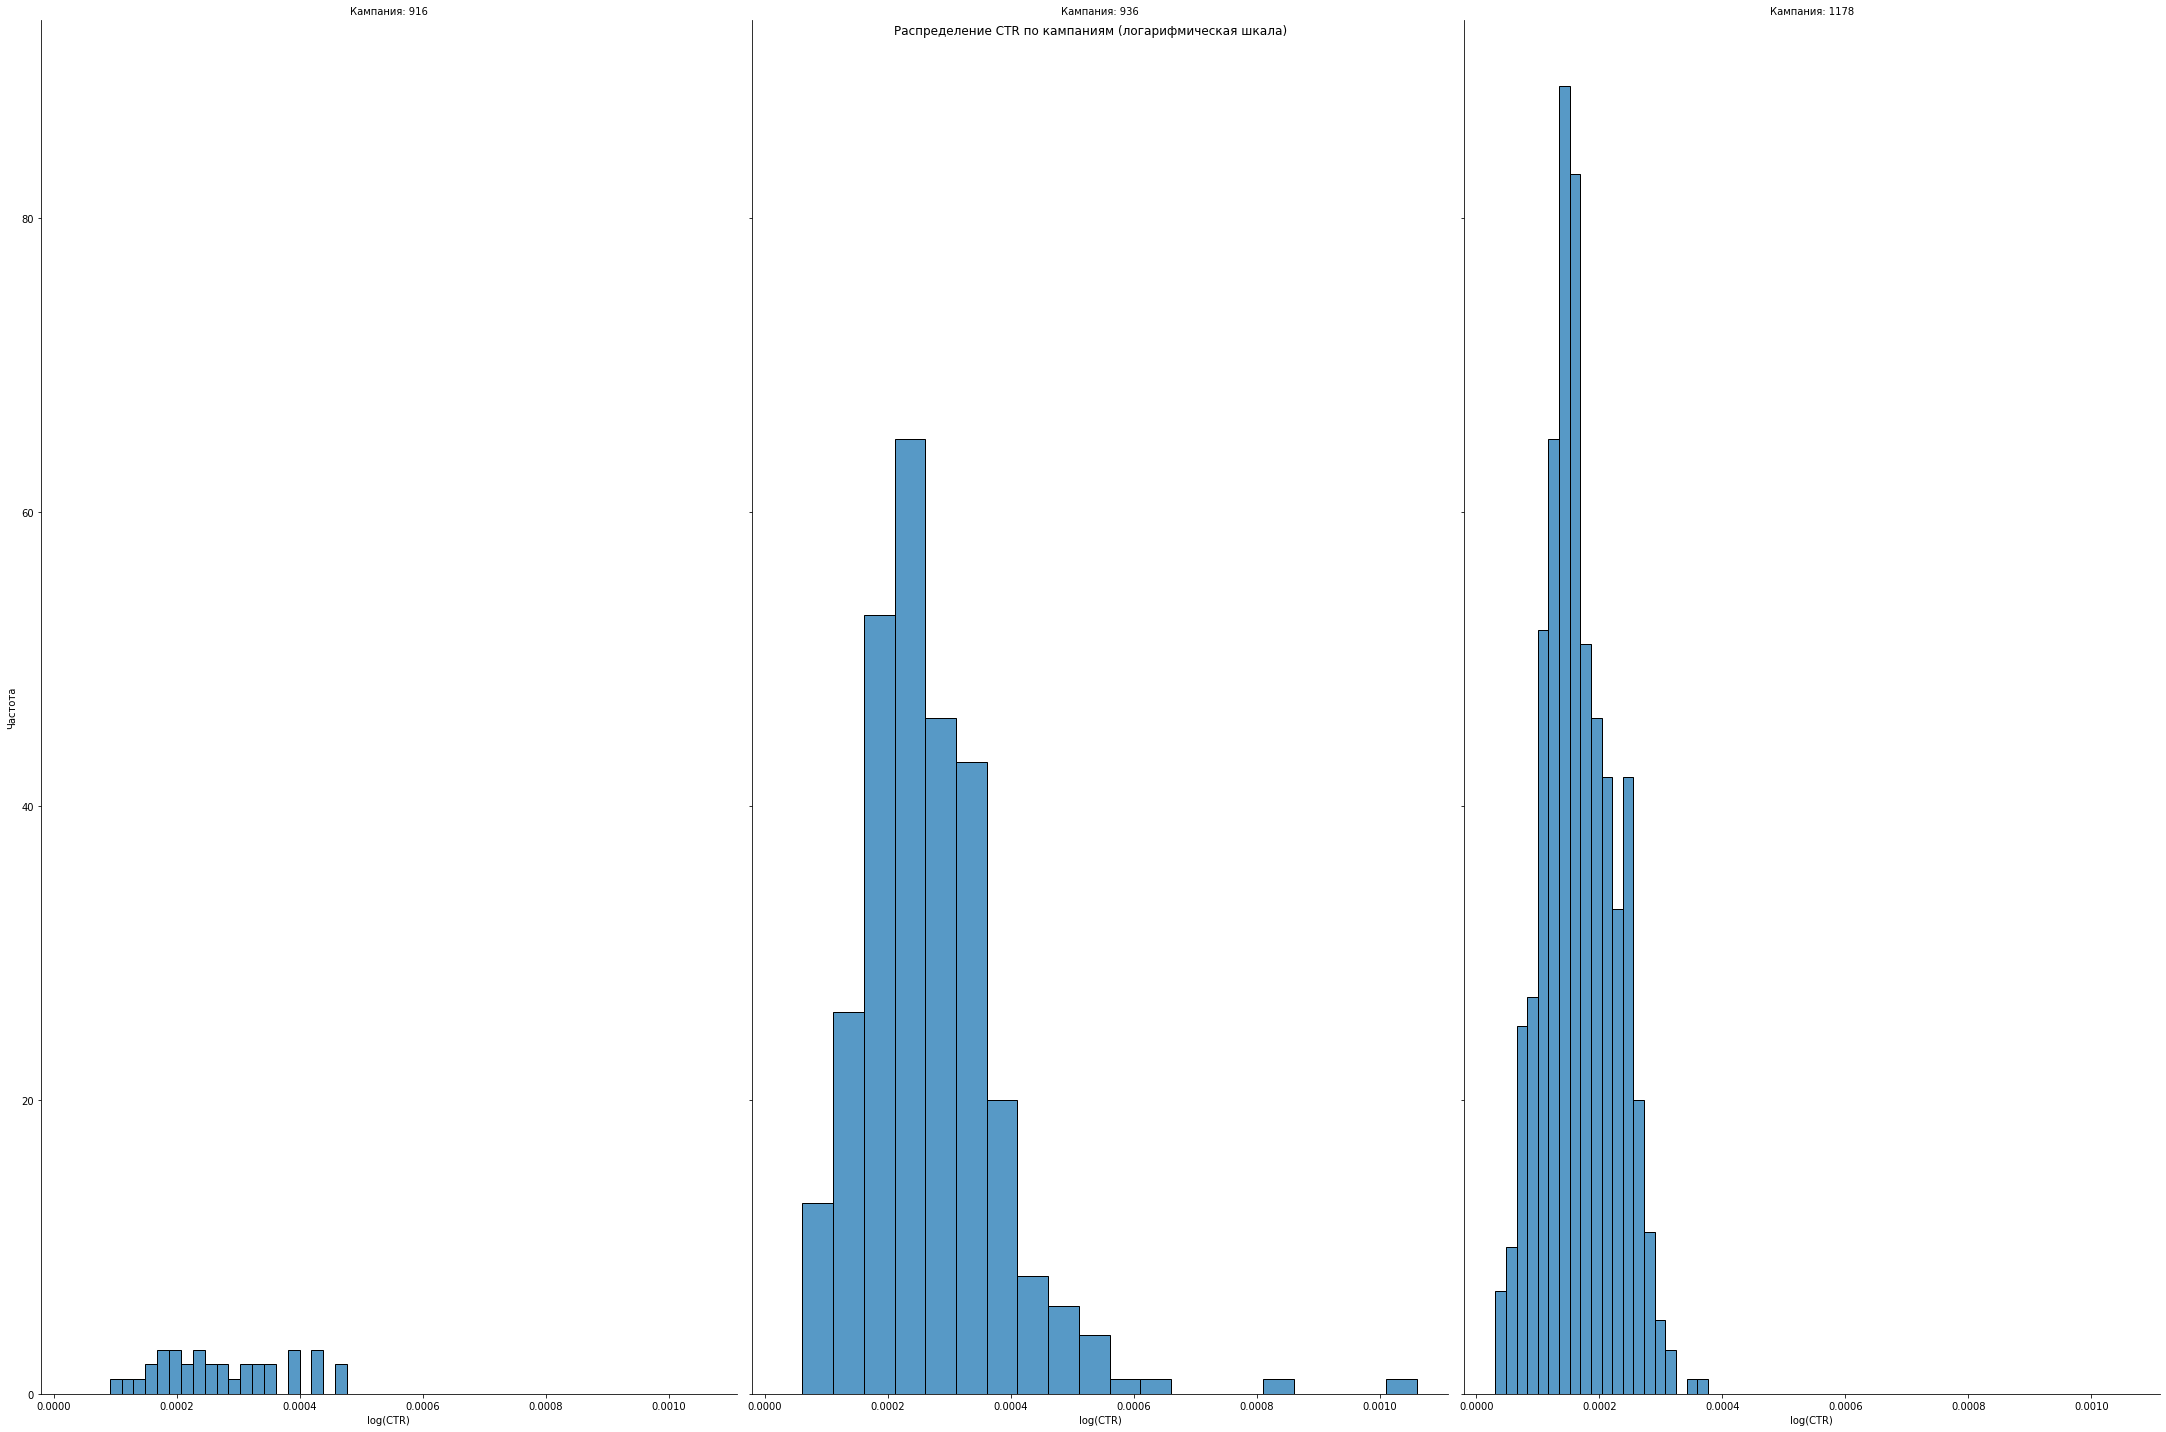

In [16]:
g = sns.FacetGrid(filtered_data, col="xyz_campaign_id", height=20, aspect=0.5, palette="viridis")
g.map(sns.histplot, "CTR", bins=20, kde=False)
g.set_titles("Кампания: {col_name}")
g.set_axis_labels("log(CTR)", "Частота")
g.fig.suptitle("Распределение CTR по кампаниям (логарифмическая шкала)")
plt.show()

/opt/tljh/user/lib/python3.7/site-packages/ipykernel_launcher.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  if __name__ == '__main__':


Описательные статистики CPC:
 count    936.000000
mean       1.499347
std        0.232879
min        0.180000
25%        1.390000
50%        1.498273
75%        1.644364
max        2.212000
Name: CPC, dtype: float64

Межквартильный размах (IQR): 0.25


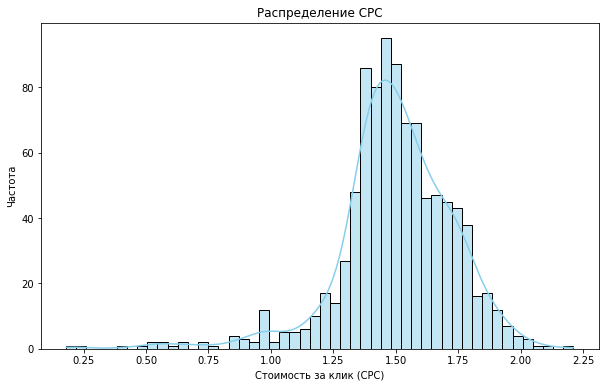

In [18]:
from scipy.stats import iqr
# Загрузка данных
data = pd.read_csv("conversion.csv")

# Фильтрация строк с кликами > 0
filtered_data2 = data[data["Clicks"] > 0]

# Расчет CPC
filtered_data2["CPC"] = filtered_data2["Spent"] / filtered_data2["Clicks"]

# Описательные статистики
stats = filtered_data2["CPC"].describe()
print("Описательные статистики CPC:\n", stats)

# Расчет межквартильного размаха
cpc_iqr = iqr(filtered_data2["CPC"], nan_policy='omit')
print(f"\nМежквартильный размах (IQR): {round(cpc_iqr, 2)}")

# Визуализация распределения
plt.figure(figsize=(10, 6))
sns.histplot(
    filtered_data2["CPC"].dropna(), 
    bins=50, 
    kde=True,
    color='skyblue'
)
plt.title("Распределение CPC")
plt.xlabel("Стоимость за клик (CPC)")
plt.ylabel("Частота")
plt.show()

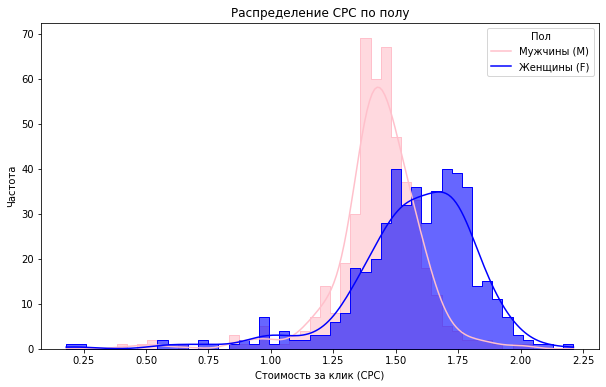

In [20]:
# Визуализация распределения CPC по полу
plt.figure(figsize=(10, 6))
sns.histplot(
    data=filtered_data2.dropna(subset=['gender']),  # Удаляем строки с NaN в поле 'gender'
    x='CPC',
    hue='gender',
    bins=50,
    kde=True,
    palette={'M': 'blue', 'F': 'pink'},  # Цвета для M и F
    alpha=0.6,  # Прозрачность для наглядности
    element='step'  # Тип отображения гистограммы
)
plt.title("Распределение CPC по полу")
plt.xlabel("Стоимость за клик (CPC)")
plt.ylabel("Частота")
plt.legend(title="Пол", labels=['Мужчины (M)', 'Женщины (F)'])
plt.show()

In [21]:
13/421

0.030878859857482184